In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('datasets/car_sales/archive(1)/Car_sales.csv')
df.head()

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


In [14]:
df.Latest_Launch = pd.to_datetime(df.Latest_Launch)

In [42]:
print('\033[42m            Basic information                 \033[0m\n')
print(df.info())
print(f"\033[34m\nDescriptive statistics for numeric values:\033[0m\n{df.describe(include=np.number)}")
print(f"\033[34m\nDescriptive statistics for objects:\033[0m\n{df.describe(include='object')}")
print('\n\033[42m              Unique values                   \033[0m')
print(f"\033[34m\nManufacturer: \033[0m\n{df.Manufacturer.value_counts()}")
print(f"\033[34m\nNumber of unique models: \033[0m {len(df.Model.value_counts())}")
print(f"\033[34m\nVehicle type: \033[0m\n{df.Vehicle_type.value_counts()}")
print('\n\033[42m                 Range                      \033[0m')
print(f"\033[34m\nRange of sales: \033[0m {(df.Sales_in_thousands.min())*1000} - {(df.Sales_in_thousands.max())*1000}")
print(f"\033[34m\nRange of year resale value: \033[0m {(df.__year_resale_value.min())} - {(df.__year_resale_value.max())}")
print(f"\033[34m\nRange of price: \033[0m {(df.Price_in_thousands.min())*1000} - {(df.Price_in_thousands.max())*1000}")
print(f"\033[34m\nRange of Engine size: \033[0m {(df.Engine_size.min())} - {(df.Engine_size.max())}")
print(f"\033[34m\nRange of power: \033[0m {(df.Horsepower.min())} - {(df.Horsepower.max())}")
print(f"\033[34m\nRange of wheelbase: \033[0m {(df.Wheelbase.min())} - {(df.Wheelbase.max())}")
print(f"\033[34m\nRange of width and length: \033[0m {(df.Width.min())} - {(df.Width.max())}; {(df.Length.min())} - {(df.Length.max())}")
print(f"\033[34m\nRange of curb weight: \033[0m {(df.Curb_weight.min())} - {(df.Curb_weight.max())}")
print(f"\033[34m\nRange of fuel capacity: \033[0m {(df.Fuel_capacity.min())} - {(df.Fuel_capacity.max())}")
print(f"\033[34m\nRange of fuel efficiency: \033[0m {(df.Fuel_efficiency.min())} - {(df.Fuel_efficiency.max())}")
print('\n\033[42m             Missed/Duplicated                  \033[0m')
print(f"\033[34m\nThe number of missed values for each category:\033[0m\n{df.isna().sum()}")
print(f"\033[34m\nThe number of duplicated for each category:\033[0m {(df.duplicated()==True).sum()}")

            Basic information                 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Manufacturer         157 non-null    object        
 1   Model                157 non-null    object        
 2   Sales_in_thousands   157 non-null    float64       
 3   __year_resale_value  121 non-null    float64       
 4   Vehicle_type         157 non-null    object        
 5   Price_in_thousands   155 non-null    float64       
 6   Engine_size          156 non-null    float64       
 7   Horsepower           156 non-null    float64       
 8   Wheelbase            156 non-null    float64       
 9   Width                156 non-null    float64       
 10  Length               156 non-null    float64       
 11  Curb_weight          155 non-null    float64       
 12  Fuel_capacity        156 non-null    float64

Decided to not fill missing values for resale value, around 20% for just 157 observations too much.

In [46]:
for k, i in df.drop(['Manufacturer','Model','Sales_in_thousands','__year_resale_value','Vehicle_type','Latest_Launch'], axis=1).items():
    if df[k].dtype == 'object':
        df.loc[:,k]=df.loc[:,k].fillna(df.loc[:,k].mode()[0])
    else:
        df.loc[:,k]=df.loc[:,k].fillna(df.loc[:,k].median())

In [70]:
dist_cols=['Sales_in_thousands', '__year_resale_value', 'Price_in_thousands', 'Engine_size', 'Horsepower',
       ['Wheelbase', 'Width', 'Length'], 'Curb_weight', ['Fuel_capacity','Fuel_efficiency'],'Power_perf_factor']
palette_dist = ['Set1',  'Dark2','Set2',  'Accent','Set3',  'Paired','Pastel1','tab10','Pastel2','husl']
colors=  [
    '#4C72B0',
    '#DD8452',
    '#55A868',
    '#C44E52',
    '#8172B3',
    '#937860',
    '#DA8BC3',
    '#8C8C8C',
    '#CCB974',
    '#64B5CD'
]

/tmp/ipykernel_3763/1781252273.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[c], label=c, kde=True, stat='density', alpha=0.5, palette='Paired')
/tmp/ipykernel_3763/1781252273.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[c], label=c, kde=True, stat='density', alpha=0.5, palette='Paired')
/tmp/ipykernel_3763/1781252273.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[c], label=c, kde=True, stat='density', alpha=0.5, palette='Paired')
/tmp/ipykernel_3763/1781252273.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[c], label=c, kde=True, stat='density', alpha=0.5, palette='Paired')
/tmp/ipykernel_3763/1781252273.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[c], label=c, kde=True, stat='density', alpha=0.5, palette='Pair

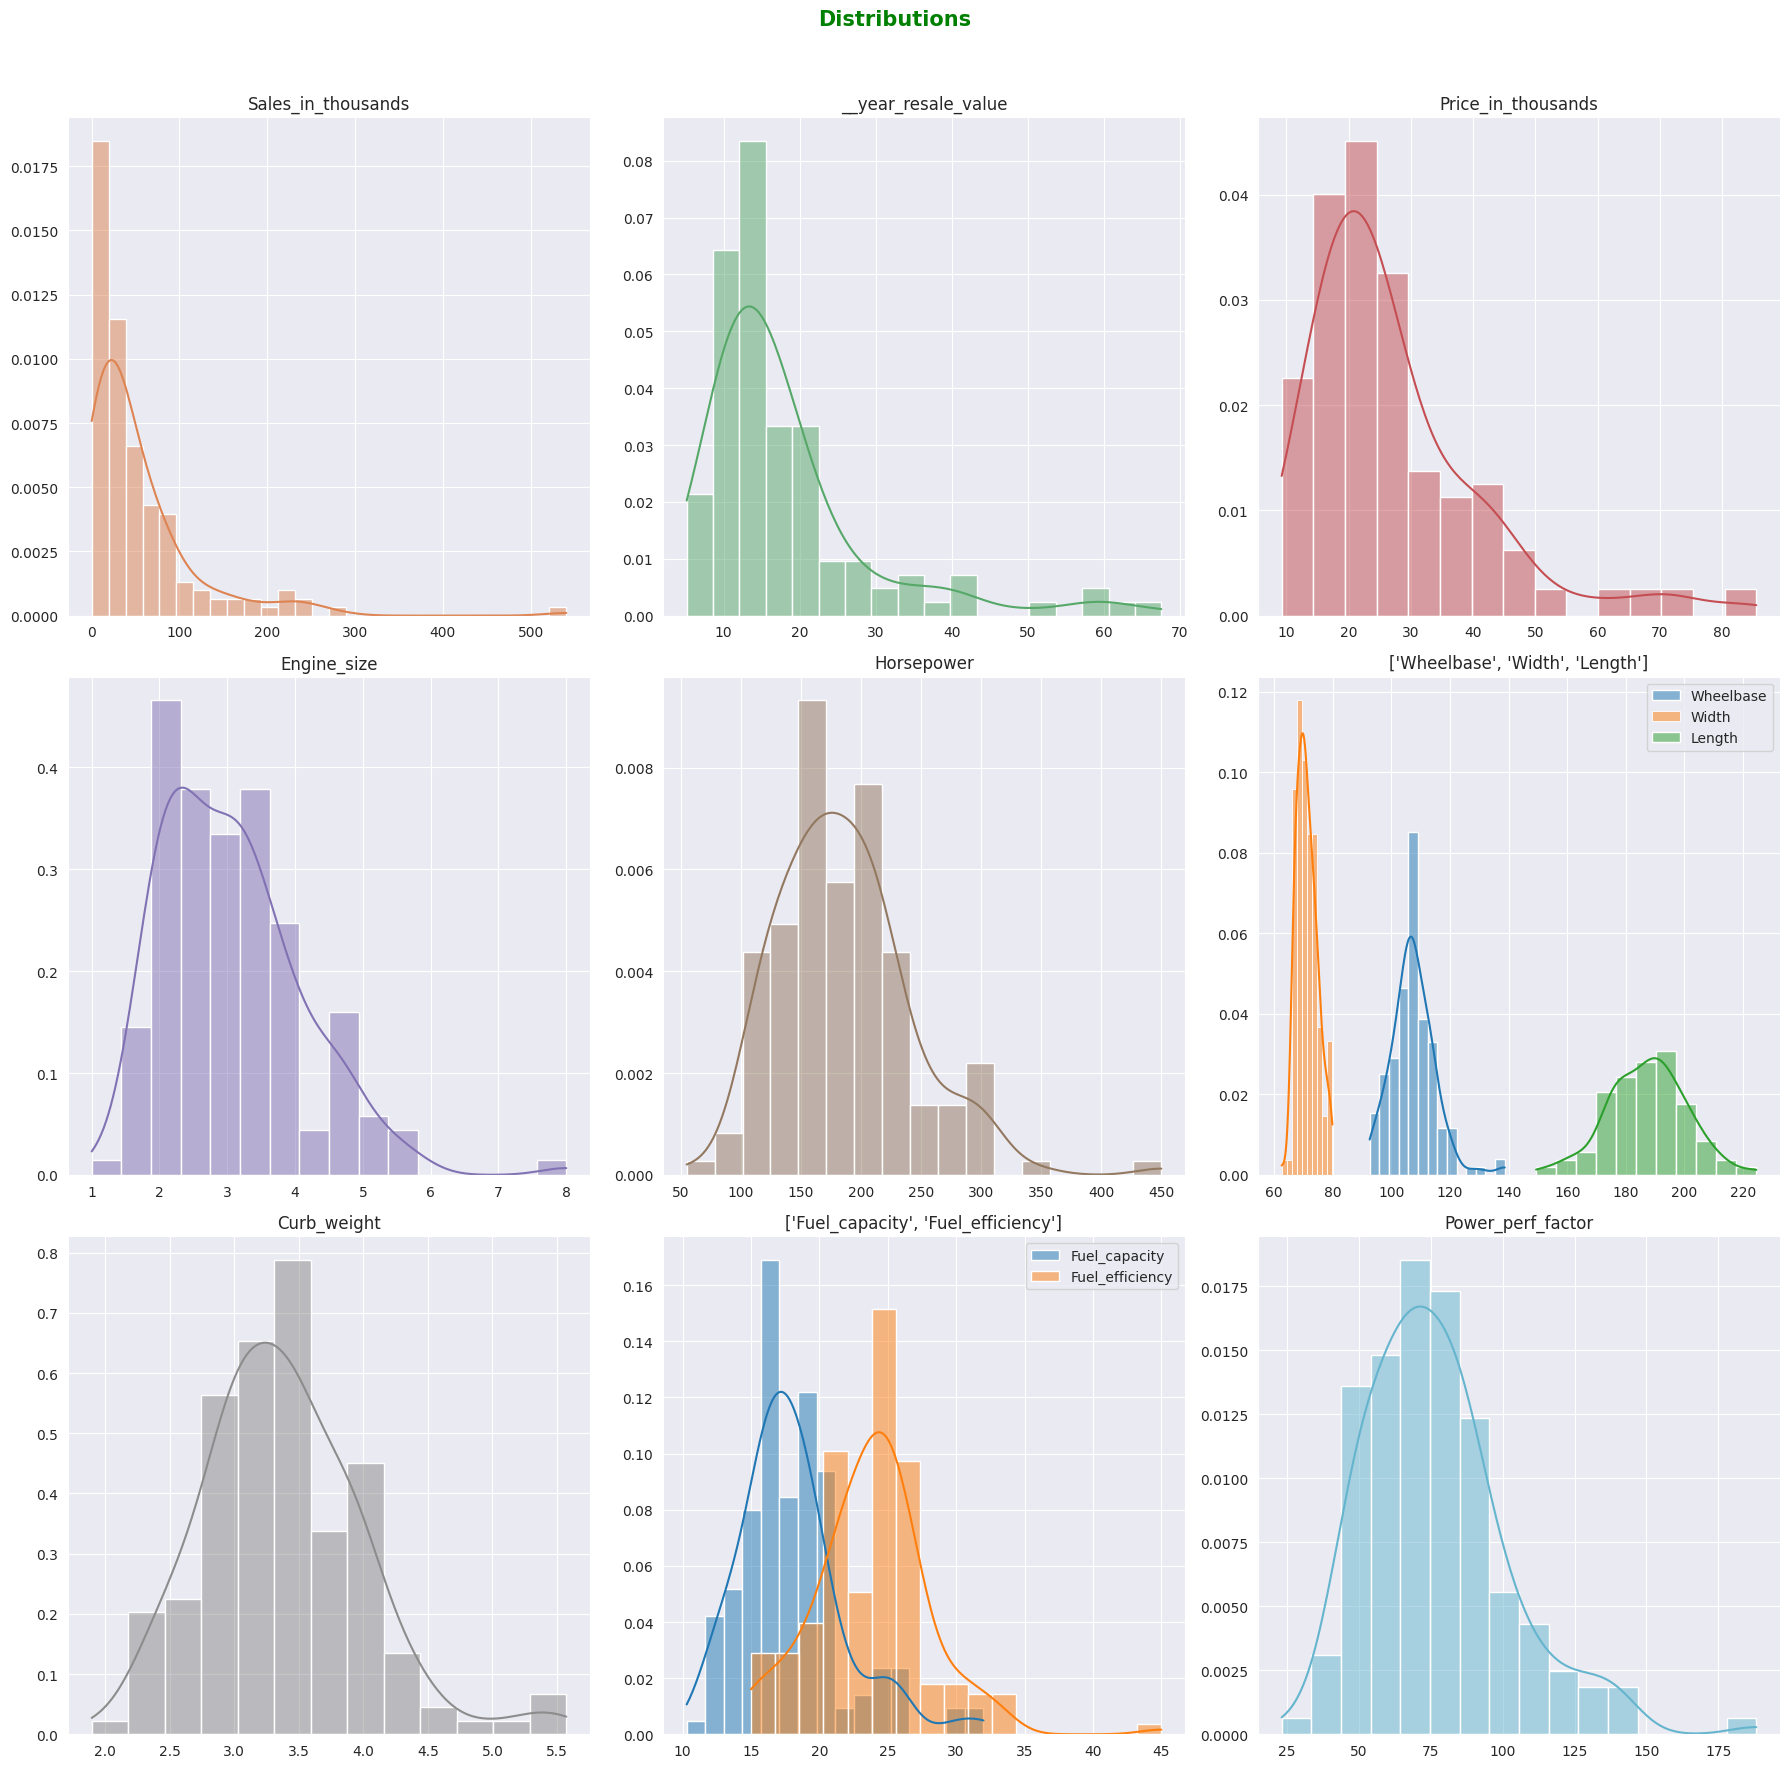

In [80]:
sns.set_style('darkgrid')
plt.figure(figsize=(18,18))
plt.suptitle('Distributions', fontsize=15, fontweight='bold', color='green')


for i, col in enumerate(dist_cols, 1):
    plt.subplot(3, 3, i)
    if isinstance(col, list):
        for c in col:
            sns.histplot(df[c], label=c, kde=True, stat='density', alpha=0.5, palette='Paired')
            plt.xlabel('')
            plt.ylabel('')
        plt.legend()
    else:    
        sns.histplot(df[col], label=col, kde=True, stat='density', alpha=0.5, color=colors[i])
        plt.xlabel('')
        plt.ylabel('')
    plt.title(str(col))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show();

In [120]:
sales_price_manifacturer = round((df.groupby('Manufacturer')[['Sales_in_thousands','Price_in_thousands']].aggregate(['mean','sum']))*1000, 2)
sales_price_model = round((df.groupby(['Manufacturer','Model'])[['Sales_in_thousands','Price_in_thousands']].mean())*1000, 2)

In [159]:
sales_manifacturer = ((sales_price_manifacturer['Sales_in_thousands']['sum']).astype(int)).sort_values()

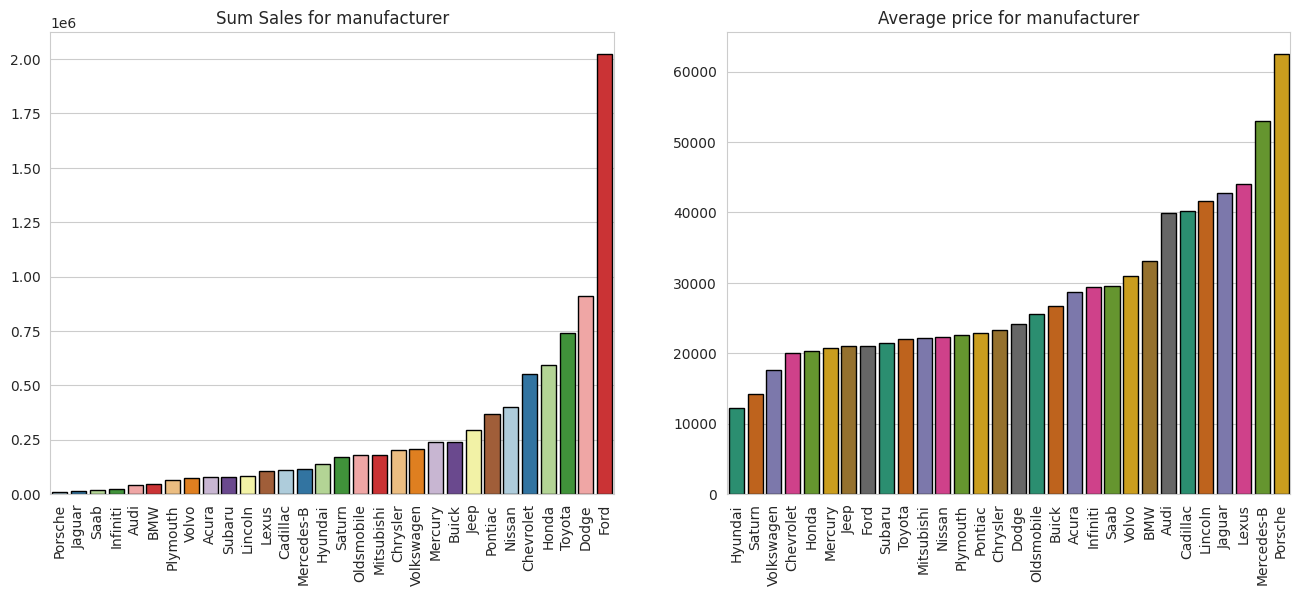

In [162]:
sns.set_style('whitegrid')
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sales_manifacturer = (sales_price_manifacturer['Sales_in_thousands']['sum']).sort_values()
sns.barplot(x=sales_manifacturer.index, y=sales_manifacturer.values, palette='Paired', hue=sales_manifacturer.values, legend=False, edgecolor='black')
plt.title('Sum Sales for manufacturer')
plt.xlabel('')
plt.xticks(rotation=90)

plt.subplot(1,2,2)
price_manifacturer = (sales_price_manifacturer['Price_in_thousands']['mean']).sort_values()
sns.barplot(x=price_manifacturer.index, y=price_manifacturer.values, palette='Dark2', hue=price_manifacturer.values, legend=False, edgecolor='black')
plt.title('Average price for manufacturer')
plt.xlabel('')
plt.xticks(rotation=90)
plt.show();

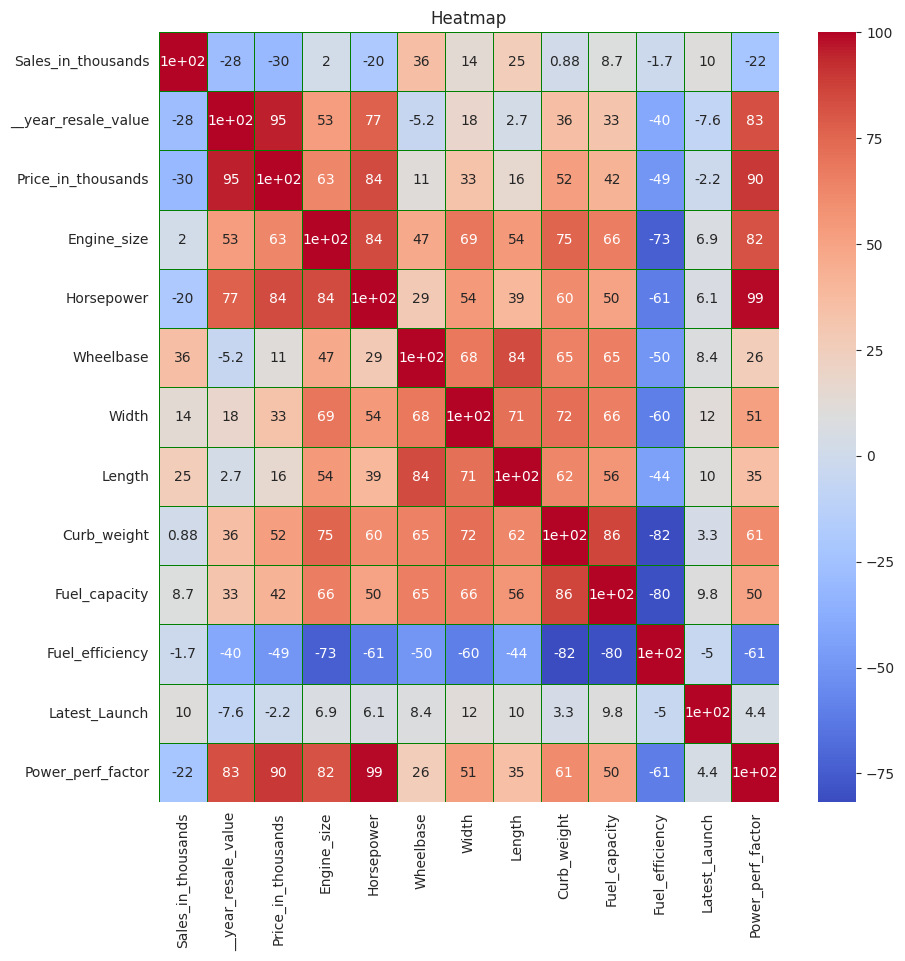

In [177]:
corr=df.drop(['Manufacturer','Model','Vehicle_type'], axis=1).corr() *100
plt.figure(figsize=(10,10))
sns.heatmap(corr, cmap='coolwarm', annot=True, linewidths=0.5, linecolor='green')
plt.title('Heatmap')
plt.show();

In [175]:
df.head(1)

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.36,Passenger,21.5,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2012-02-02,58.28015


In [176]:
df.columns

Index(['Manufacturer', 'Model', 'Sales_in_thousands', '__year_resale_value',
       'Vehicle_type', 'Price_in_thousands', 'Engine_size', 'Horsepower',
       'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity',
       'Fuel_efficiency', 'Latest_Launch', 'Power_perf_factor'],
      dtype='object')

In [179]:
df['year'] = df.Latest_Launch.dt.year
df['month'] = df.Latest_Launch.dt.month

In [187]:
print(f"\033[34mRange of Latest Launch: \033[0m{df.Latest_Launch.min()} - {df.Latest_Launch.max()}")
print(f"\n\033[34mNumber of models launched for years: \033[0m\n{df.year.value_counts()}")

Range of Latest Launch: 2008-02-13 00:00:00 - 2012-12-29 00:00:00

Number of models launched for years: 
year
2011    79
2012    75
2009     2
2008     1
Name: count, dtype: int64
